# CHME 212 — Midterm Exam 2

**Time allowed: 35 minutes (33 minutes for problem-solving, 2 minutes for submission preparation)**  
**Open notes, closed internet.**

---

### Instructions

1. **Submission:** Enter all answers in the provided notebook (Canvas-Files-Exam) and submit it through **Gradescope** before time is called. Late submissions will not be accepted.

2. **Electronic devices:** All personal electronic devices (phones, tablets, smartwatches) are **strictly prohibited**. Internet access and AI/code assistant tools (ChatGPT, GitHub Copilot, etc.) are **strictly prohibited**. Any violation will be treated as a violation of academic integrity.

3. **Open notes:** You may use printed or handwritten notes only.

4. **Before submitting:** Restart the kernel and run all cells to confirm your notebook runs without errors.

### Run this cell if package installation is required. If not, ignore.

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib", "scipy", "-q"])

## Student Information

In [ ]:
name  = ""        # Your full name

---

## Part A — Multiple Choice (30 pts, 10 pts each; ⏱ ~3 min, ~1 min each, ideally <30 sec each)

Answer each question by assigning the correct letter in the answer cell below.

### Q1

Which of the following correctly matches each `matplotlib` method to what it draws?

**(A)** `plt.plot` → scatter points,  `plt.scatter` → line,  `plt.hist` → histogram  
**(B)** `plt.plot` → line,  `plt.scatter` → scatter points,  `plt.hist` → histogram  
**(C)** `plt.plot` → histogram,  `plt.scatter` → line,  `plt.hist` → scatter points  
**(D)** `plt.plot` → line,  `plt.scatter` → histogram,  `plt.hist` → scatter points

 > **Solution:** **(B)** — `plt.plot` draws a line, `plt.scatter` draws scatter points, `plt.hist` draws a histogram.

### Q2

A project is organized like this:

```
reactor_tools/
    __init__.py
    kinetics.py
    thermodynamics.py
```

Which import correctly brings in the `kinetics` module so you can call `kinetics.rate(T)` from outside the package?

**(A)** `import kinetics`  
**(B)** `from reactor_tools import kinetics`  
**(C)** `import reactor_tools`  
**(D)** `from kinetics import reactor_tools`

 > **Solution:** **(B)** — `from reactor_tools import kinetics` imports the `kinetics` module from the package, allowing `kinetics.rate(T)` to be called.

### Q3

```python
import numpy as np
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])
```

Which line produces `[15, 18, 21, 24]` (the sum of each column)?

**(A)** `np.sum(matrix)`  
**(B)** `np.sum(matrix, axis=1)`  
**(C)** `np.sum(matrix, axis=0)`  
**(D)** `np.mean(matrix, axis=0)`

 > **Solution:** **(C)** — `np.sum(matrix, axis=0)` sums along axis 0 (rows), producing the column sums `[15, 18, 21, 24]`.

In [ ]:
import numpy as np
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

np.sum(matrix, axis=0)

array([15, 18, 21, 24])

---

## Part B — Coding Problems (70 pts)

Read each problem carefully and fill in the blanks marked with `TODO`, or complete the code as instructed. Do not modify the pre-provided lines.

---

### Q1 — Numerical Integration & Polynomial Fitting (20 pts; ⏱ ~8 min)

A steam process requires heating from 400 K to 1000 K. The heat capacity $C_p$ of steam was measured at seven temperatures:

```python
T_data  = np.array([400,  500,  600,  700,  800,  900, 1000])  # K
Cp_data = np.array([34.3, 35.2, 36.3, 37.5, 38.6, 39.7, 40.8])  # J/mol·K
```

The enthalpy change is $\Delta H = \displaystyle\int_{400}^{1000} C_p(T)\,dT$.

**(Task 1 — 7 pts):** Using the trapezoidal rule on the tabulated data, compute $\Delta H$ in J/mol directly from the tabulated data.

**(Task 2 — 13 pts):** Define a Python function `Cp_fit(T)` that **evaluates** the fitted polynomial, then recompute $\Delta H$ in J/mol from the fitted curve.

In [ ]:
import numpy as np
from scipy.integrate import trapezoid, quad

T_data  = np.array([400,  500,  600,  700,  800,  900, 1000])  # K
Cp_data = np.array([34.3, 35.2, 36.3, 37.5, 38.6, 39.7, 40.8])  # J/mol·K

# Task 1 — trapezoidal integration on tabulated data
dH_trap = trapezoid(Cp_data, T_data)
print(f"Task 1  ΔH (trapezoid) = {dH_trap:.3f} J/mol")

# Task 2 — integrate the fitted polynomial with quad
coeffs = np.polyfit(T_data, Cp_data, 1)  # linear fit with 1st degree polynomial

def Cp_fit(T):
    return np.polyval(coeffs, T)  # evaluate the polynomial at T

dH_quad, _ = quad(Cp_fit, 400, 1000)  # integrate Cp_fit from 400 to 1000 K
print(f"\nTask 2  ΔH (quad fit)  = {dH_quad:.3f} J/mol")
print(f"        Difference     = {abs(dH_trap - dH_quad):.4f} J/mol")

In [ ]:
# Task 2 — integrate the fitted polynomial with quad
coeffs = np.polyfit(T_data, Cp_data, 1)  # linear fit with 1st degree polynomial

def Cp_fit(T):
    return np.polyval(coeffs, T)  # evaluate the polynomial at T

dH_quad, _ = quad(Cp_fit, 400, 1000)  # integrate Cp_fit from 400 to 1000 K
print(f"\nTask 2  ΔH (quad fit)  = {dH_quad:.3f} J/mol")
print(f"        Difference     = {abs(dH_trap - dH_quad):.4f} J/mol")

---

### Q2 — Monte Carlo Simulation (25 pts; ⏱ ~8 min)

A shell-and-tube heat exchanger heats a process stream. The outlet temperature is modeled as:

$$T_{out} = T_{in} + \frac{Q}{\dot{m} \, c_p}$$

where:
- $T_{in} = 25\,°C$ (fixed inlet temperature)
- $Q = 5000\,\text{W}$ (fixed heat duty)
- $c_p = 4.18\,\text{J g}^{-1}\,°C^{-1}$ (fixed heat capacity of water)
- $\dot{m} \sim \mathcal{N}(100,\;5^2)\,\text{g/s}$ (mass flow rate, **normally distributed**)

The outlet temperature must be **at least 35 °C** to meet process requirements.

**(Task 1 — 8 pts):** Compute $T_{out}$ at the mean flow rate $\dot{m} = 100\,\text{g/s}$. Does it meet the spec?

**(Task 2 — 17 pts):** Generate $N = 50{,}000$ samples of $\dot{m}$ and compute $T_{out}$ for each. Then find:
- Mean and standard deviation of $T_{out}$
- Fraction of runs where $T_{out} < 35\,°C$ (failure rate)

In [ ]:
import numpy as np

T_in = 25.0    # °C
Q    = 5000.0  # W
cp   = 4.18    # J/(g·°C)
spec_T = 35.0  # °C

# Task 1 — nominal outlet temperature at mean flow rate
mdot_mean = 100.0   # g/s
T_nominal = T_in + Q / (mdot_mean * cp)

print(f"Nominal T_out = {T_nominal:.2f} °C")
print(f"Meets spec?   {'YES' if T_nominal >= spec_T else 'NO'}")

# Task 2 — Monte Carlo
N   = 50_000
rng = np.random.default_rng(seed=42)

mdot_samples = rng.normal(100, 5, N)         # sample N values from N(100, 5^2)
T_samples    = T_in + Q / (mdot_samples * cp)  # compute T_out for each sample

mean_T    = np.mean(T_samples)
std_T     = np.std(T_samples, ddof=1)
fail_rate = np.mean(T_samples < spec_T)

print(f"\nMonte Carlo results (N = {N:,}):")
print(f"  Mean T_out   = {mean_T:.2f} °C")
print(f"  Std T_out    = {std_T:.2f} °C")
print(f"  Failure rate = {fail_rate*100:.2f}%")

---

### Q3 — Heat & Mass Balance (25 pts; ⏱ ~14 min)

A mixing unit combines two feed streams and produces a single outlet stream. Each stream carries three components (A, B, C) and has its own temperature.

**Stream data:**

| | Stream 1 | Stream 2 | Outlet |
|---|---|---|---|
| Total flow (kg/h) | $F_1$ | $F_2$ | 500 |
| Mass fraction A | 0.60 | 0.20 | 0.40 |
| Mass fraction B | 0.30 | 0.50 | — |
| Mass fraction C | 0.10 | 0.30 | — |
| Temperature (°C) | 80 | 40 | $T_{out}$ |
| $c_p$ (kJ/kg·°C) | 3.5 | 4.2 | 3.8 |

The mixer operates at **steady state** with **no heat loss** to the surroundings.
Assume constant heat capacities, negligible heat of mixing, and a common reference temperature for all streams. Use the given outlet c_p value directly in the energy balance.

**(Task 1 — 10 pts):** Set up and solve the **2×2 linear system** for $F_1$ and $F_2$ using the total mass balance and component A balance.

**(Task 2 — 10 pts):** Compute the outlet temperature $T_{out}$ using the energy balance equation. Think about what "steady state, no heat loss" implies: all the thermal energy carried in by the feed streams must equal the thermal energy carried out by the outlet stream. Each stream's thermal energy rate is proportional to its flow rate, heat capacity, and temperature.

**(Task 3 — 5 pts):** If $F_1$ increases while $F_2$ stays the same, would $T_{out}$ go **up or down**?

#### **!!!Run the below cell for visualization!!!**  After running, please collapse the code cell (in JupyterLab, click the small arrow to the left of the cell, use View → Collapse Selected Code, or click the vertical bar next to the cell).

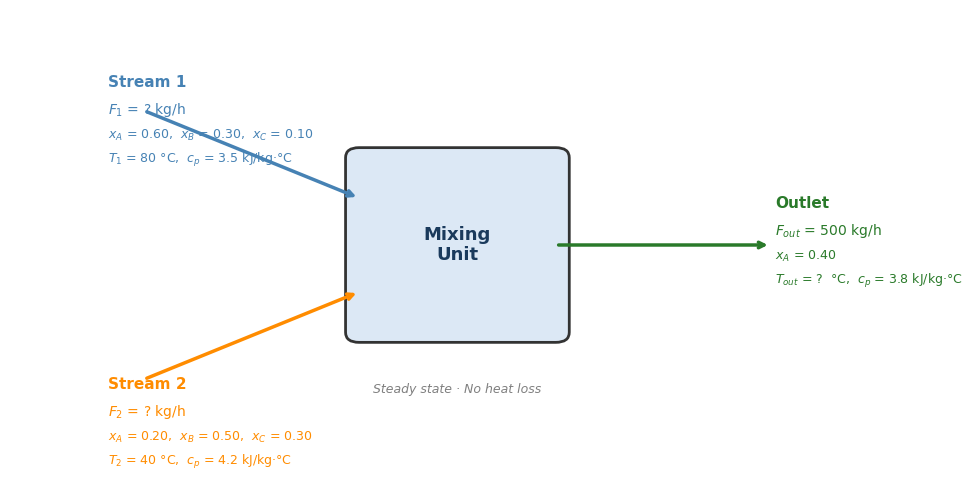

In [ ]:
## !!!!!!! THIS IS NOT THE PROBLEM CODE!!!!!!!
### ONLY FOR VISUALIZATION PURPOSES — COLLAPSE THIS CELL AFTER RUNNING !!!!!!! ###
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

# --- Mixer box ---
box = mpatches.FancyBboxPatch((3.9, 2.2), 2.2, 2.6,
                               boxstyle="round,pad=0.15",
                               linewidth=2, edgecolor='#333333',
                               facecolor='#dce8f5')
ax.add_patch(box)
ax.text(5.0, 3.5, 'Mixing\nUnit', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#1a3a5c')

# --- Stream 1 arrow (top-left → mixer) ---
ax.annotate('', xy=(3.9, 4.2), xytext=(1.5, 5.5),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.text(1.1, 5.85, 'Stream 1', fontsize=11, fontweight='bold', color='steelblue')
ax.text(1.1, 5.45, '$F_1$ = ? kg/h', fontsize=10, color='steelblue')
ax.text(1.1, 5.08, '$x_A$ = 0.60,  $x_B$ = 0.30,  $x_C$ = 0.10', fontsize=9, color='steelblue')
ax.text(1.1, 4.72, '$T_1$ = 80 °C,  $c_p$ = 3.5 kJ/kg·°C', fontsize=9, color='steelblue')

# --- Stream 2 arrow (bottom-left → mixer) ---
ax.annotate('', xy=(3.9, 2.8), xytext=(1.5, 1.5),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5))
ax.text(1.1, 1.35, 'Stream 2', fontsize=11, fontweight='bold', color='darkorange')
ax.text(1.1, 0.95, '$F_2$ = ? kg/h', fontsize=10, color='darkorange')
ax.text(1.1, 0.58, '$x_A$ = 0.20,  $x_B$ = 0.50,  $x_C$ = 0.30', fontsize=9, color='darkorange')
ax.text(1.1, 0.22, '$T_2$ = 40 °C,  $c_p$ = 4.2 kJ/kg·°C', fontsize=9, color='darkorange')

# --- Outlet arrow (mixer → right) ---
ax.annotate('', xy=(8.5, 3.5), xytext=(6.1, 3.5),
            arrowprops=dict(arrowstyle='->', color='#2a7a2a', lw=2.5))
ax.text(8.55, 4.05, 'Outlet', fontsize=11, fontweight='bold', color='#2a7a2a')
ax.text(8.55, 3.65, '$F_{out}$ = 500 kg/h', fontsize=10, color='#2a7a2a')
ax.text(8.55, 3.28, '$x_A$ = 0.40', fontsize=9, color='#2a7a2a')
ax.text(8.55, 2.92, '$T_{out}$ = ?  °C,  $c_p$ = 3.8 kJ/kg·°C', fontsize=9, color='#2a7a2a')

# --- Steady-state / adiabatic label ---
ax.text(5.0, 1.3, 'Steady state · No heat loss', ha='center', fontsize=9,
        color='gray', style='italic')

plt.tight_layout()
plt.show()
## !!!!!!! THIS IS NOT THE PROBLEM CODE!!!!!!!
### ONLY FOR VISUALIZATION PURPOSES — COLLAPSE THIS CELL AFTER RUNNING !!!!!!! ###

In [ ]:
import numpy as np

# Known stream properties
F_out  = 500.0   # kg/h
xA_out = 0.40    # outlet mass fraction of A

cp1, T1 = 3.5, 80.0   # kJ/(kg·°C), °C
cp2, T2 = 4.2, 40.0
cp_out  = 3.8          # kJ/(kg·°C)

# Task 1 — solve 2×2 system for F1 and F2
# Total mass balance:     F1 + F2 = 500
# Component A balance:    0.60*F1 + 0.20*F2 = 0.40*500 = 200
#
# In matrix form: A @ [F1, F2]^T = b
A = np.array([[1.0,  1.0],
              [0.60, 0.20]])
b = np.array([F_out, xA_out * F_out])

F1, F2 = np.linalg.solve(A, b)

print(f"F1 = {F1:.2f} kg/h")
print(f"F2 = {F2:.2f} kg/h")
print(f"Check: F1 + F2 = {F1+F2:.2f} kg/h  (expected {F_out})")

# Task 2 — Outlet temperature from energy balance
# Steady state, no heat loss:  energy in = energy out
#   F1*cp1*T1 + F2*cp2*T2 = F_out*cp_out*T_out
T_out = (F1 * cp1 * T1 + F2 * cp2 * T2) / (F_out * cp_out)

print(f"\nOutlet temperature T_out = {T_out:.2f} °C")

# Task 3 — written answer
answer = """
T_out would go UP.

Stream 1 enters at 80 °C, which is hotter than Stream 2 (40 °C).
If F1 increases while F2 stays fixed, F_out also increases, but the extra
mass carries more thermal energy at the higher temperature T1.
The numerator (F1*cp1*T1 + F2*cp2*T2) grows faster than the denominator
(F_out * cp_out), so T_out rises toward T1 = 80 °C.
"""
print(answer)